# Linear Regression

**Linear regression** is a supervised machine learning algorithm that uses labeled data to learn the best-fitting linear function for mapping input variables to output variables. It operates under the assumption that there is a straight-line (linear) relationship between input and output—meaning changes in the input cause proportional changes in the output.  

For instance, consider predicting a student’s exam score based on study hours. Generally, as study hours increase, exam scores tend to rise.

+ Independent variable (input): Hours studied (the factor we control or observe)
+ Dependent variable (output): Exam score (the value we aim to predict based on study hours)  

In this scenario, we use the independent variable to predict the dependent variable.
learn more about linear regression [here]()



## importing libraries 


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.axes as ax
from matplotlib.animation import FuncAnimation

###  Build the Linear Regression Model and Plot the regression line


In forward propagation Linear regression function **Y=mx+c** is applied by initially assigning random value of parameter (m and c). The we have written the function to finding the cost function i.e the mean 




In [2]:
class LinearRegression: 
    def __init__(self): 
        self.parameters = {}
    def forward_propagation(self, x): 
        # x is the input feature, m is the slope, c is the y-intercept 
        # This function calculate the predictions based on the linear equation Y = mx + c 
        m = self.parameters['m']
        c = self.parameters['c']
        predictions = np.multiply(x, m) + c
        return predictions
    def cost_function(self, x, y):
        """
        This function calculate the cost function for linear regression. 
        input: 
            x: input features 
            y: actual output values
            
        output: 
            cost: mean squared error between predicted and actual values. 
        """

        cost = np.mean((x - y) ** 2)
        return cost
    def backward_propagation(self, x, y, predictions): 
        """
            This function calculates the derivatives of the cost function with respect to the parameters m and c.
            df is the difference between the predicted values and actual values. derivatives predictions according to the actual values.
            dm is the derivatives of predictions according to m.
            dc is the derivatives of predictions according to c.           
            input: 
                x: input features 
                y: actual output values 
                predictions: predicted output values based on the current parameters m and c
            output: 
                derivatives: a dictionary containing the derivatives of the cost function with respect to m and c
        """
        derivatives = {}
        df = (predictions - y) 
        dm = 2 * np.mean(np.multiply(x, df))
        dc = 2 * np.mean(df)
        derivatives["dm"]=dm
        derivatives["dc"]=dc
        return derivatives 
    def update_parameters(self, derivatives, learning_rate):
        """
            This function updates the parameters m and c using the derivatives and learning rate.
            input: 
                derivatives: a dictionary containing the derivatives of the cost function with respect to m and c
                learning_rate: a scalar value that determines the step size for updating the parameters
            output: 
                None, but updates the parameters m and c in the self.parameters dictionary
        """
        self.parameters['m'] -= learning_rate * derivatives['dm']
        self.parameters['c'] -= learning_rate * derivatives['dc']

    def train(self, x, y, learning_rate, iters): 
        """
            This function trains the linear regression model using the input features x and actual output values y.
            It performs forward propagation, calculates the cost function, performs backward propagation, and updates the parameters m and c.
            input: 
                x: input features 
                y: actual output values 
                learning_rate: a scalar value that determines the step size for updating the parameters
                iters: number of iterations to perform during training
            output: 
                None, but updates the parameters m and c in the self.parameters dictionary
        """
        self.parameters['m'] = np.random.uniform(0, 1) * -1
        self.parameters['c'] = np.random.uniform(0, 1) * -1
        self.loss = [] 

        fig, ax = plt.subplots() 
        x_vals = np.linspace(min(x), max(x), 100) 
        line, = ax.plot(x_vals, self.parameters['m'] * x_vals + self.parameters['c'], color='red', label='Regression Line') 
        ax.scatter(x, y, marker='o', color='green', label='Training Data') 

        ax.set_ylim(0, max(y) + 1) 


        def update(frame): 
            predictions = self.forward_propagation(x) 
            cost = self.cost_function(predictions, y) 
            derivatives = self.backward_propagation(x, y, predictions) 
            self.update_parameters(derivatives, learning_rate) 
            line.set_ydata(self.parameters['m'] * x_vals + self.parameters['c']) 
            self.loss.append(cost) 
            print("Iteration = {}, Loss = {}".format(frame + 1, cost)) 
            return line, 

        ani = FuncAnimation(fig, update, frames=iters, interval=200, blit=True) 
        ani.save('linear_regression_A.gif', writer='ffmpeg') 

        plt.xlabel('Input') 
        plt.ylabel('Output') 
        plt.title('Linear Regression') 
        plt.legend() 
        plt.show() 

        return self.parameters, self.loss 




### Load the dataset and separate input and Target variables

In [9]:
from kagglehub import KaggleDatasetAdapter

url = 'https://media.geeksforgeeks.org/wp-content/uploads/20240320114716/data_for_lr.csv'
data = pd.read_csv(url)

data = data.dropna()

train_input = np.array(data.x[0:500]).reshape(500, 1)
train_output = np.array(data.y[0:500]).reshape(500, 1)

test_input = np.array(data.x[500:700]).reshape(199, 1)
test_output = np.array(data.y[500:700]).reshape(199, 1)

### train Linear Regression


MovieWriter ffmpeg unavailable; using Pillow instead.


Iteration = 1, Loss = 9460.127166813762
Iteration = 1, Loss = 1146.9401789337273
Iteration = 1, Loss = 145.11067589554108
Iteration = 1, Loss = 24.37931682885701
Iteration = 2, Loss = 9.829872806053544
Iteration = 3, Loss = 8.076505088295654
Iteration = 4, Loss = 7.865203820835135
Iteration = 5, Loss = 7.8397383425653615
Iteration = 6, Loss = 7.8366680994201765
Iteration = 7, Loss = 7.8362967259659415
Iteration = 8, Loss = 7.836250595818957
Iteration = 9, Loss = 7.836243661168597
Iteration = 10, Loss = 7.836241450140704
Iteration = 11, Loss = 7.836239808499279
Iteration = 12, Loss = 7.836238235613664
Iteration = 13, Loss = 7.836236671152404
Iteration = 14, Loss = 7.836235107844887
Iteration = 15, Loss = 7.836233544814908
Iteration = 16, Loss = 7.836231981956865
Iteration = 17, Loss = 7.836230419258016
Iteration = 18, Loss = 7.836228856716813
Iteration = 19, Loss = 7.836227294333051
Iteration = 20, Loss = 7.8362257321067


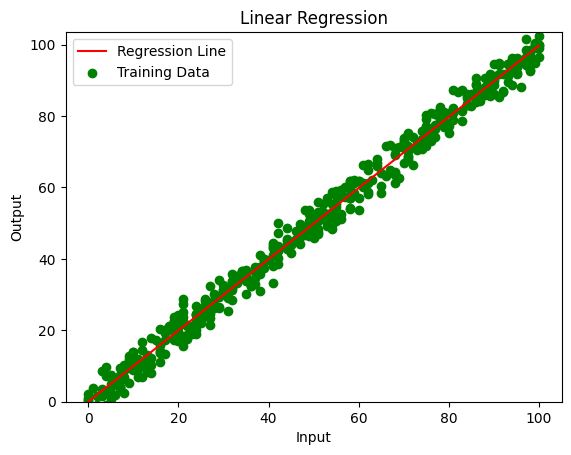

In [10]:
linear_reg = LinearRegression()
parameters, loss = linear_reg.train(train_input, train_output, 0.0001, 20)